# Pipeline — Agricultural Insurance Pricing

`Exploratory Analysis → ACRI → State Construction → Transition Model → Expected Loss/Premium → Sensitivity Analysis`

**Yang perlu Anda siapkan sebelum mulai:**
1. `AgriculturalInsurance_climate_pipeline.zip`
2. `master_research_dataset_v1.xlsx` (dari pipeline Colab sebelumnya)



## 0. Instalasi library

In [ ]:
!pip install -q seaborn scikit-learn scipy openpyxl
print("Instalasi selesai.")


Instalasi selesai.


## 1. Upload project

Klik **Choose Files** dan pilih `AgriculturalInsurance_climate_pipeline.zip`.


In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

os.chdir('AgriculturalInsurance')
print("Isi folder scripts:")
!ls scripts/


Saving AgriculturalInsurance_climate_pipeline.zip to AgriculturalInsurance_climate_pipeline.zip
Isi folder scripts:
01_prepare_boundary.py	     08_state_construction.py
02_download_chirps.py	     09_estimate_transition_model.py
03_extract_rainfall.py	     10_expected_loss_premium.py
04_download_nasa_power.py    11_sensitivity_threshold.py
05_merge_climate_dataset.py  harga_gkg_reference.py
06_exploratory_analysis.py   utils.py
07_build_acri.py


## 2. Upload master_research_dataset_v1.xlsx

Hasil dari pipeline Fase 2 (Colab sebelumnya).


In [ ]:
data_uploaded = files.upload()
DATA_FILE = list(data_uploaded.keys())[0]
print(f"Dipakai: {DATA_FILE}")


Saving master_research_dataset_v1.xlsx to master_research_dataset_v1.xlsx
Dipakai: master_research_dataset_v1.xlsx


## 3. Fase 4 — Exploratory Data Analysis

Statistik deskriptif, korelasi, tren, ranking provinsi.


In [ ]:
!python scripts/06_exploratory_analysis.py --input "{DATA_FILE}"


Data lengkap: 272 baris, 34 provinsi, tahun 2018-2025.

=== Statistik deskriptif ===
                          mean         std      min          max  cv_pct
Luas_Panen_Ha        313082.35   472168.98   113.33   1841346.00   150.8
Produktivitas_KuHa       45.61        8.61    26.53        72.76    18.9
Produksi_Ton        1635841.39  2681928.23   305.09  10499588.23   163.9
Rainfall_mm            2801.68      670.87  1217.67      4393.46    23.9
Temperature_C            25.66        1.25    23.17        28.72     4.9
Humidity_pct             85.29        3.73    74.03        91.73     4.4

=== Korelasi dengan Produktivitas ===
Luas_Panen_Ha    0.514
Rainfall_mm     -0.280
Temperature_C   -0.239
Humidity_pct    -0.200

Disimpan ke: /content/AgriculturalInsurance/outputs/eda/eda_summary_report.xlsx
Grafik (5 file PNG) disimpan di: /content/AgriculturalInsurance/outputs/eda


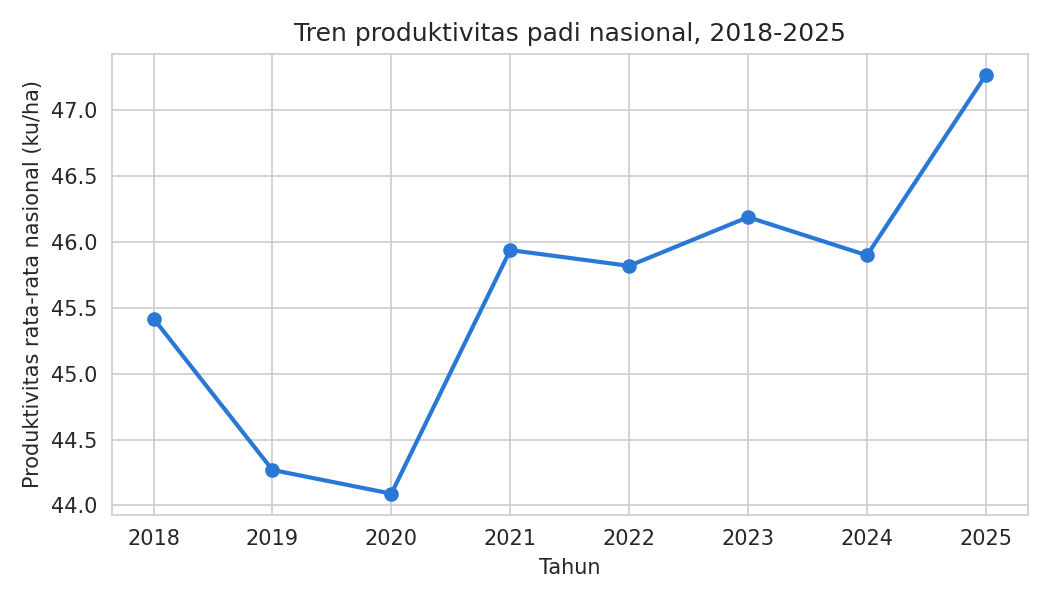

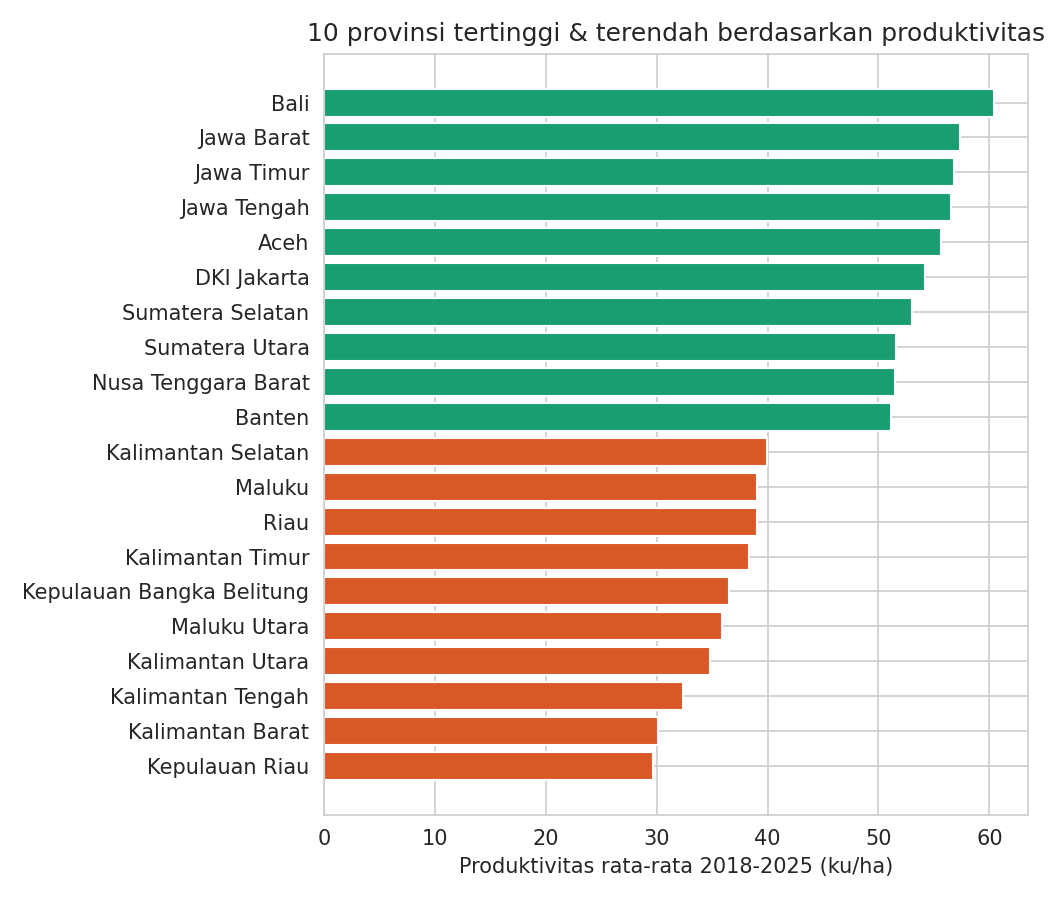

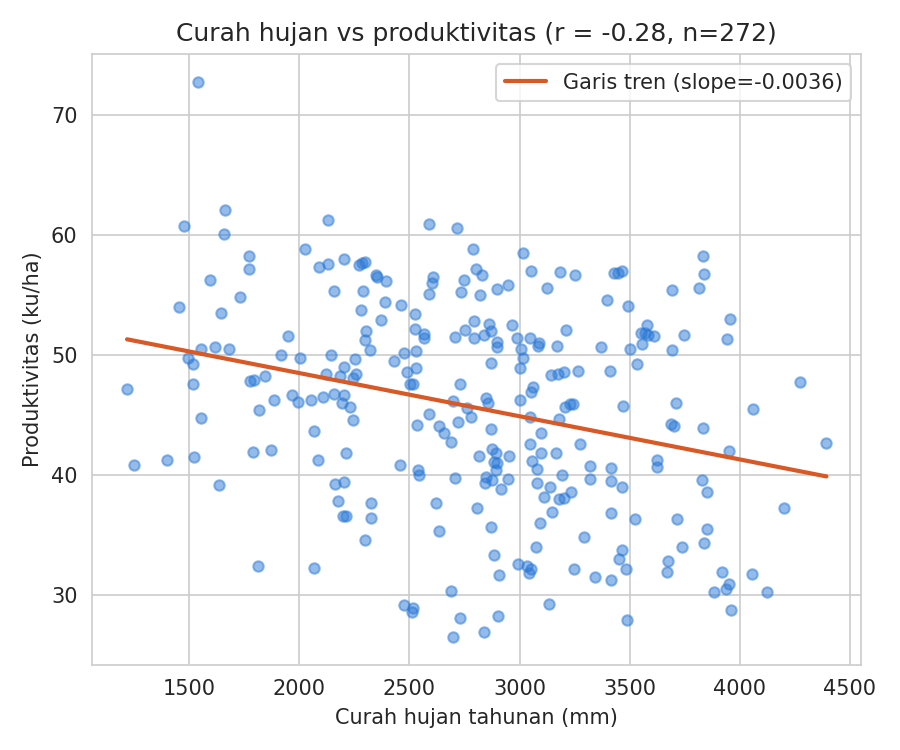

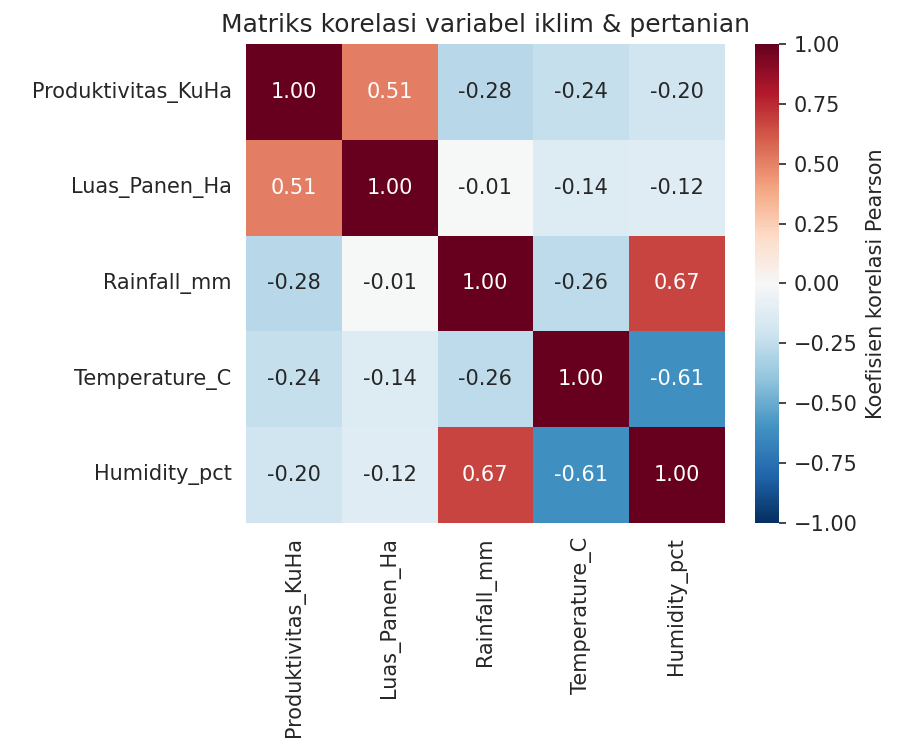

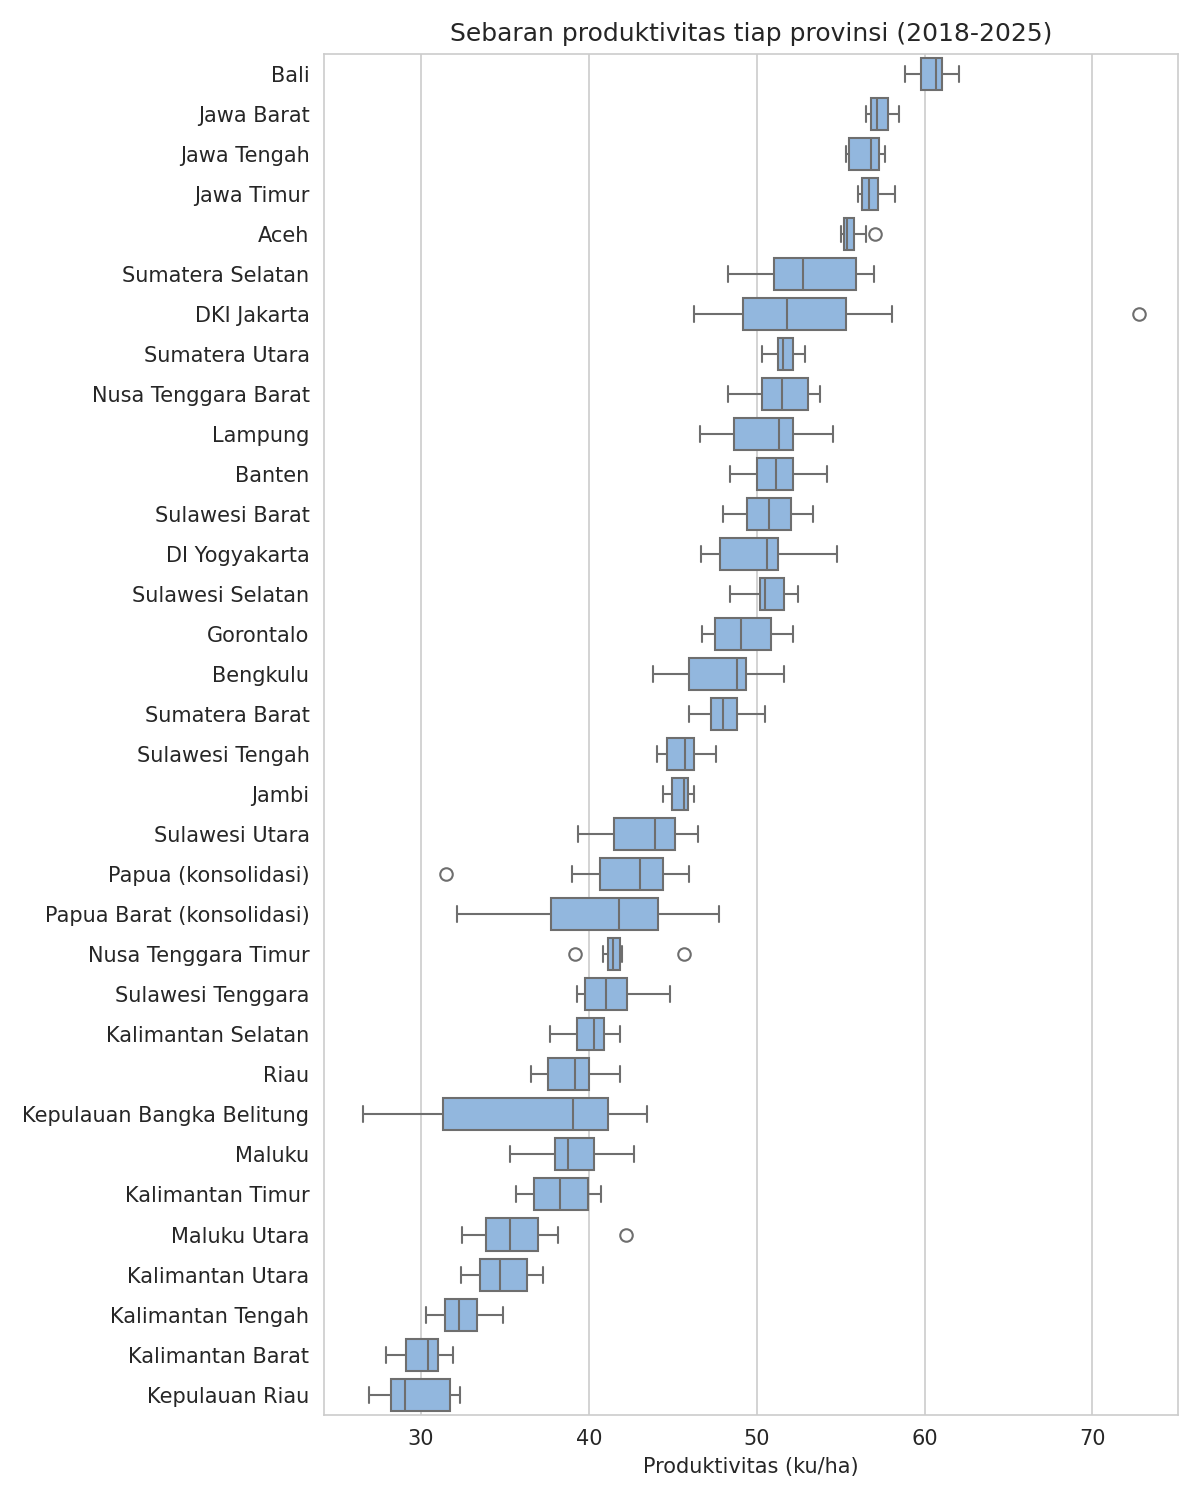

In [ ]:
from IPython.display import Image, display
import glob
for img_path in sorted(glob.glob("outputs/eda/*.png")):
    display(Image(img_path))


## 4. Fase 5 — ACRI (Agricultural Climate Risk Index)


In [ ]:
!python scripts/07_build_acri.py --input "{DATA_FILE}"


ACRI berhasil dihitung untuk 272 baris.
Rentang ACRI: 0.038 - 0.789
Rata-rata ACRI: 0.372

5 provinsi-tahun dengan ACRI tertinggi (kondisi iklim paling menyimpang):
                 Provinsi  Tahun     ACRI
                Gorontalo   2019 0.788963
                     Riau   2019 0.763506
                  Lampung   2019 0.713622
           Kepulauan Riau   2019 0.707772
Papua Barat (konsolidasi)   2024 0.679170

5 provinsi-tahun dengan ACRI terendah (kondisi iklim paling normal):
           Provinsi  Tahun     ACRI
              Jambi   2020 0.037874
   Kalimantan Timur   2020 0.042786
Papua (konsolidasi)   2020 0.092625
     Sulawesi Barat   2025 0.093368
   Sulawesi Selatan   2020 0.094239

Disimpan ke: /content/AgriculturalInsurance/outputs/acri/acri_dataset.xlsx
Grafik (3 file PNG) disimpan di: /content/AgriculturalInsurance/outputs/acri


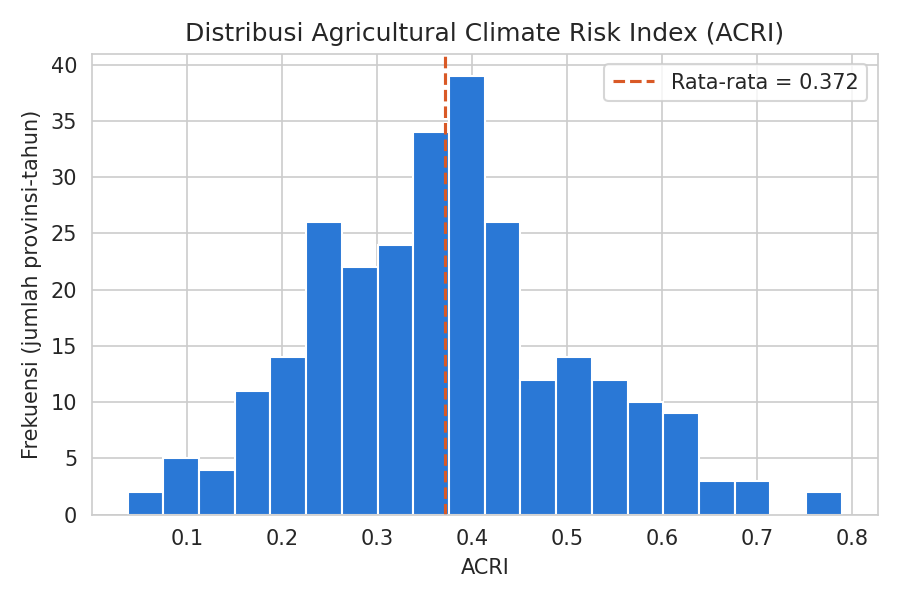

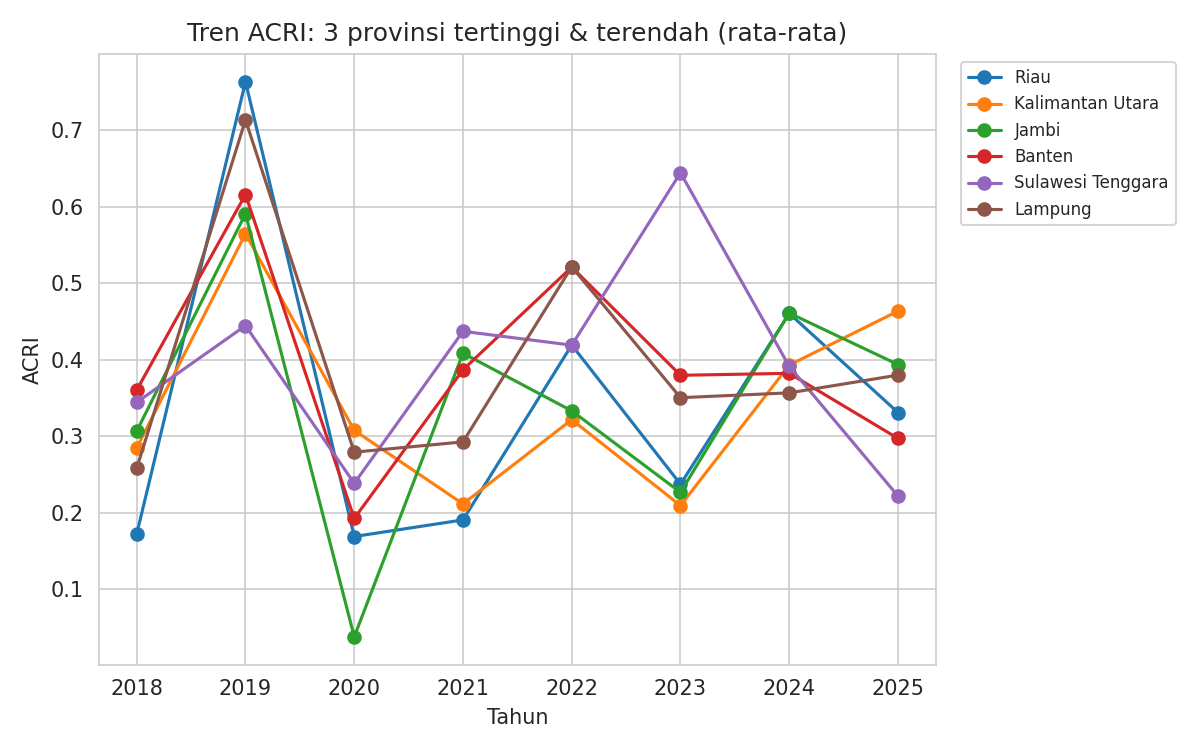

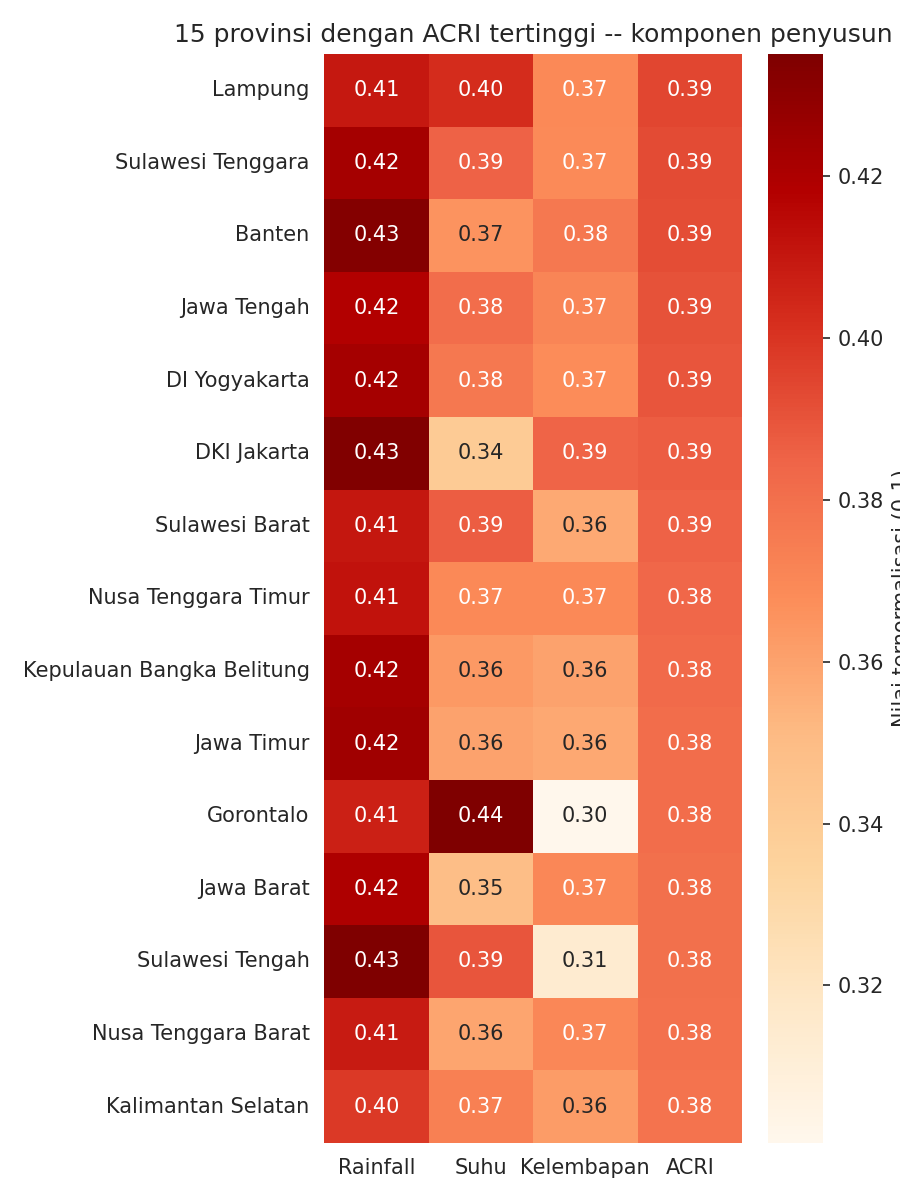

In [ ]:
for img_path in sorted(glob.glob("outputs/acri/*.png")):
    display(Image(img_path))


## 5. Fase 6 — State Construction

Klasifikasi kondisi tanaman (x1 Normal - x4 Crop Collapse), berbasis
konvensi SPI (McKee et al. 1993, disesuaikan -- lihat Metodologi di file
Excel hasilnya).


In [ ]:
!python scripts/08_state_construction.py --input "{DATA_FILE}" --acri outputs/acri/acri_dataset.xlsx


=== Distribusi state ===
       Jumlah  Persentase (%)
State                        
x1        180            66.2
x2         45            16.5
x3         36            13.2
x4         11             4.0

=== Tabel transisi teramati ===
State_next   x1  x2  x3  x4
State                      
x1          110  18  17   4
x2           23  12   5   3
x3           21   6   7   1
x4            6   4   1   0

Total transisi teramati: 238

[PERINGATAN] State x4 cuma teramati 11 kali -- estimasi parameter transisi terkait x4 di Fase 7 kemungkinan perlu regularisasi/parameter sharing.

Disimpan ke: /content/AgriculturalInsurance/outputs/state_construction/state_dataset.xlsx
Grafik (3 file PNG) disimpan di: /content/AgriculturalInsurance/outputs/state_construction


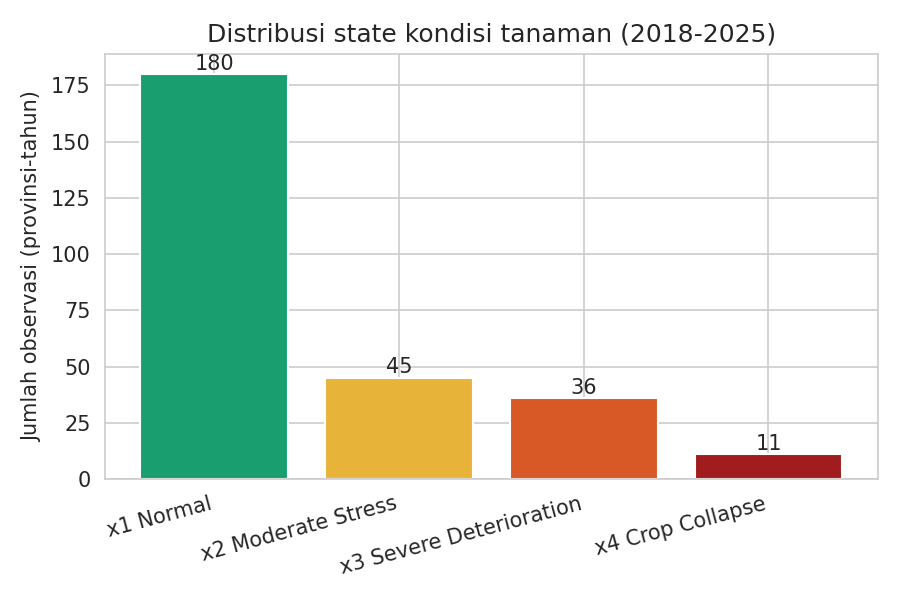

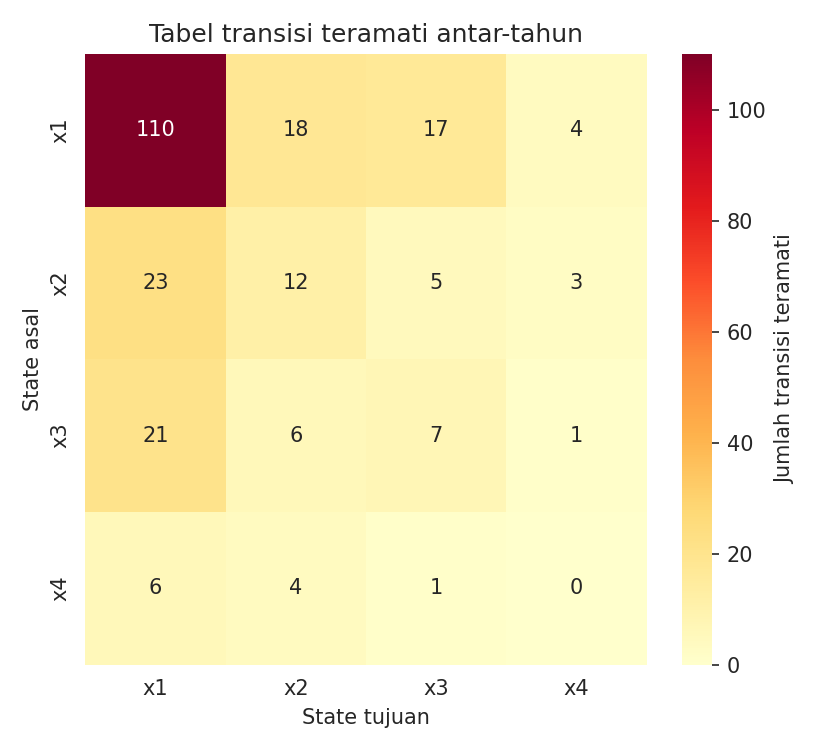

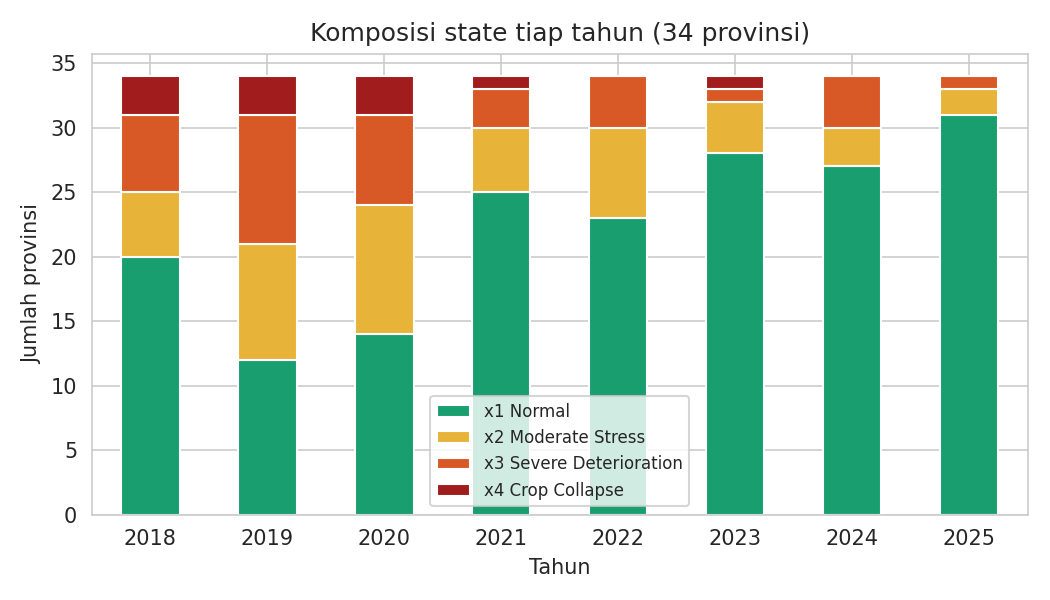

In [ ]:
for img_path in sorted(glob.glob("outputs/state_construction/*.png")):
    display(Image(img_path))


## 6. Fase 7 — Estimasi Model Transisi (gamma & q0)

Bagian paling kritis (menjawab Reviewer #4). Butuh waktu beberapa menit
karena bootstrap 200 replikasi per state asal.


In [ ]:
!python scripts/09_estimate_transition_model.py --state outputs/state_construction/state_dataset.xlsx --acri outputs/acri/acri_dataset.xlsx


Total provinsi: 34 | Train: 27 | Test (held-out): 7
Provinsi test (held-out): [np.str_('Jawa Barat'), np.str_('Kalimantan Utara'), np.str_('Maluku'), np.str_('Nusa Tenggara Barat'), np.str_('Papua Barat (konsolidasi)'), np.str_('Sulawesi Barat'), np.str_('Sulawesi Selatan')]

=== Matriks peluang transisi baseline (Z=0) ===
       x1     x2     x3     x4
x1  0.760  0.118  0.110  0.012
x2  0.613  0.261  0.102  0.025
x3  0.618  0.176  0.169  0.037
x4  0.308  0.608  0.084  0.000

=== Matriks intensitas kontinu Q (logm(P)) ===
       x1     x2     x3     x4
x1 -0.508  0.151  0.336  0.021
x2  1.397 -1.753  0.257  0.099
x3  1.342  0.944 -2.438  0.152
x4  0.000  3.289  0.115 -3.404

[CATATAN NUMERIK] Matrix logarithm menghasilkan komponen imajiner signifikan -- P mungkin bukan hasil embedding dari CTMC tunggal yang valid.; Ada elemen off-diagonal negatif pada Q hasil logm(P) -- ini masalah numerik yang dikenal ("embedding problem") pada matrix logarithm dari matriks stokastik empiris. Nilai ne

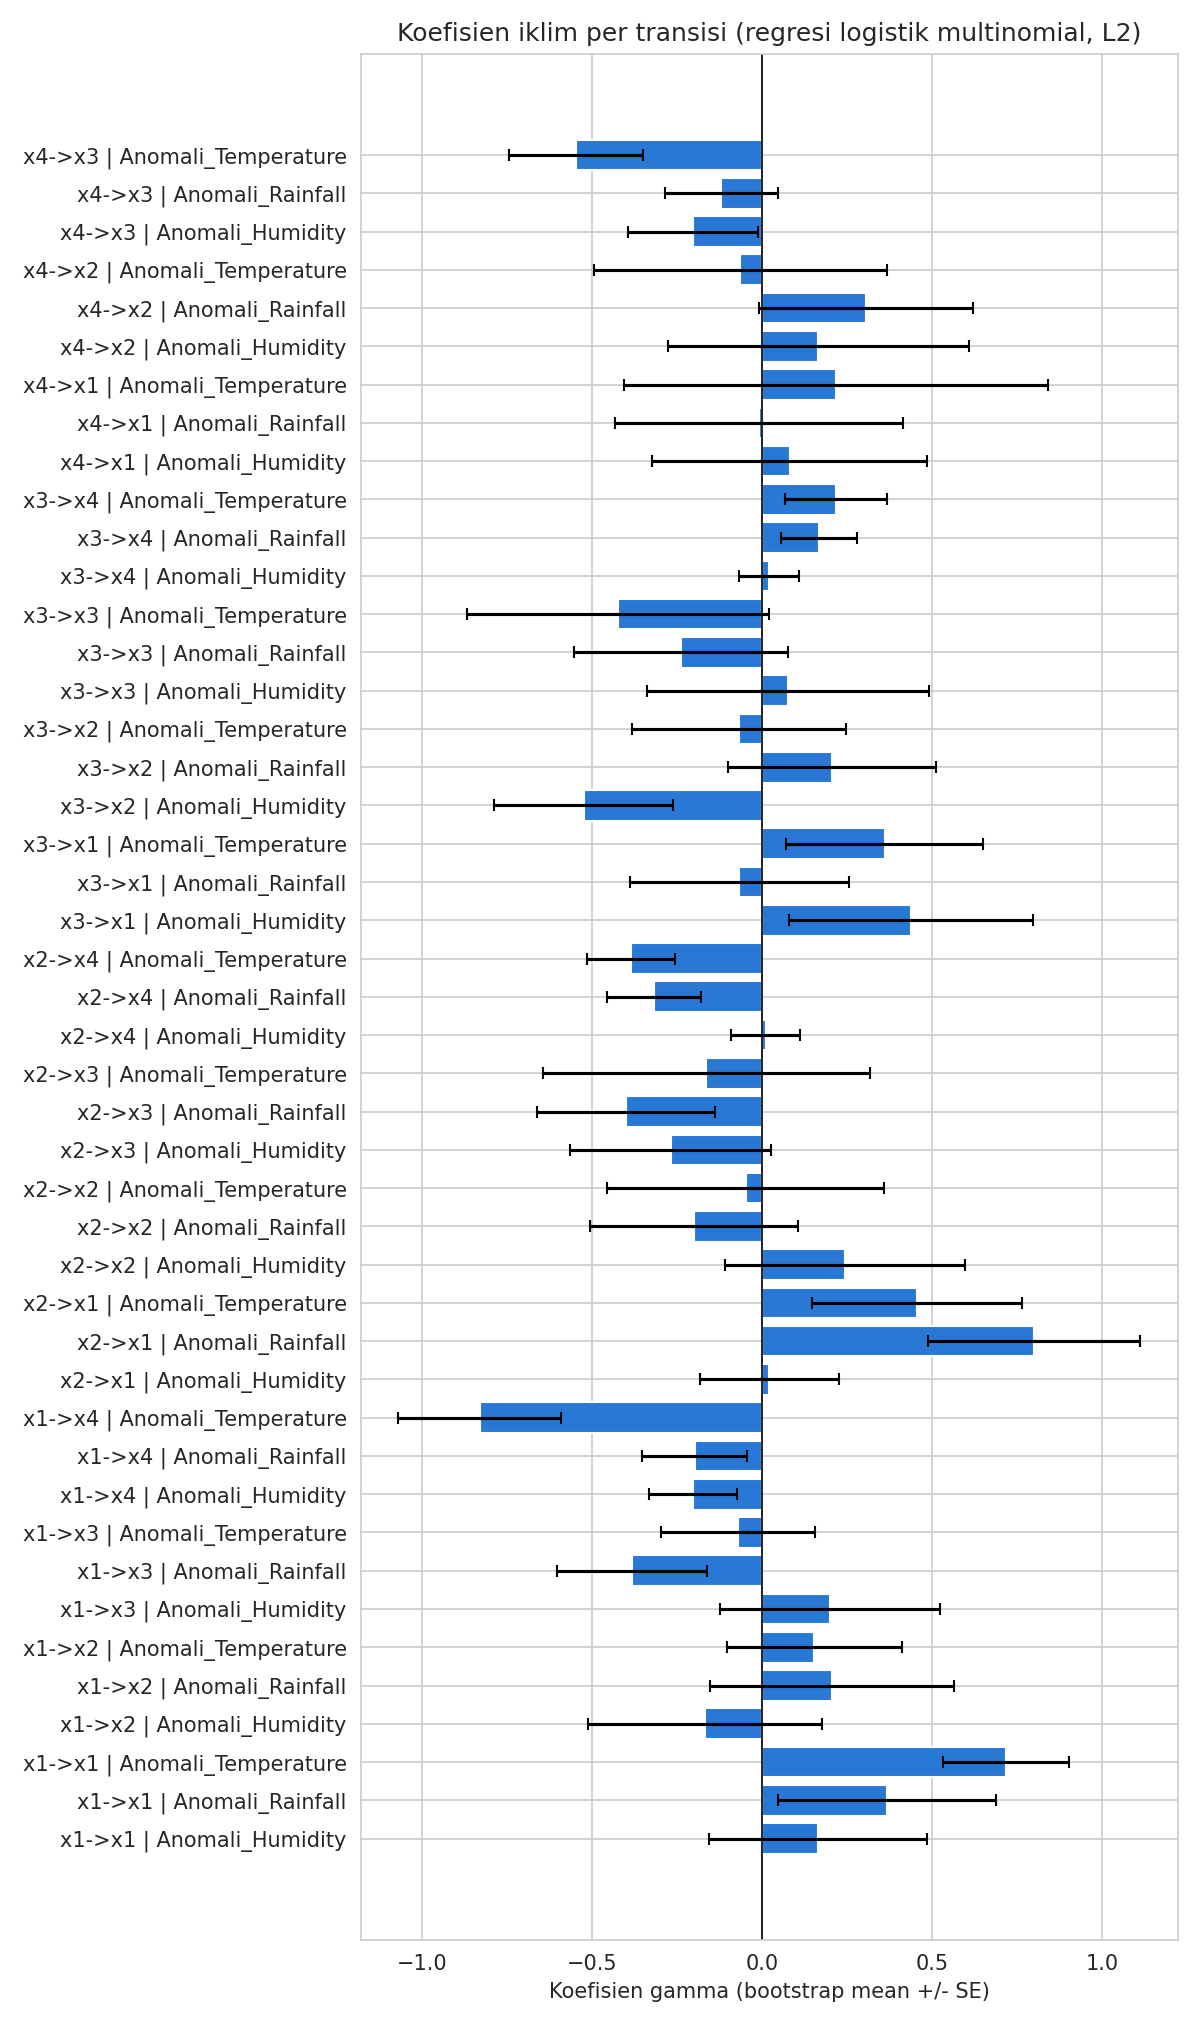

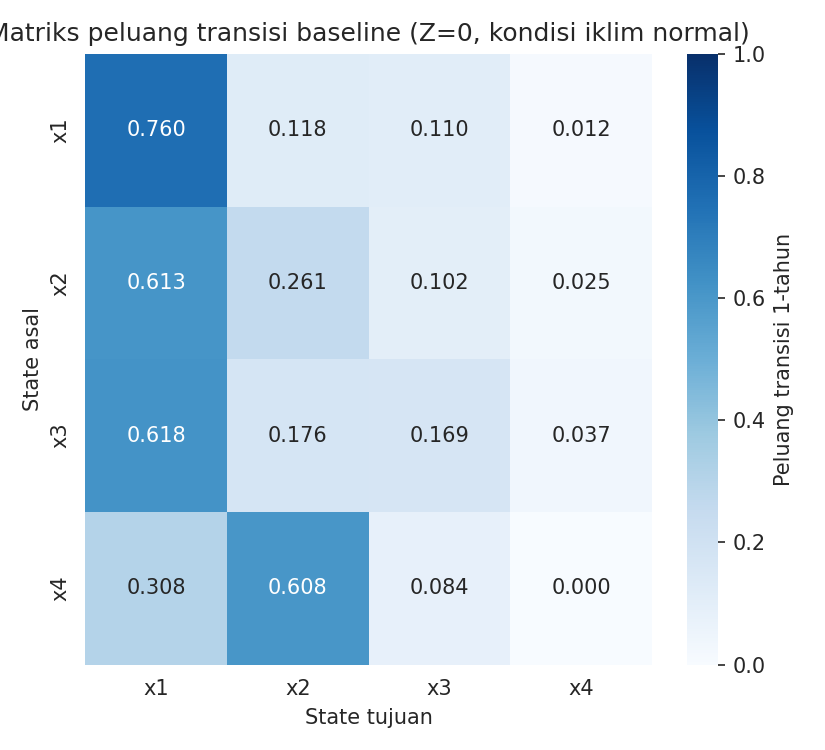

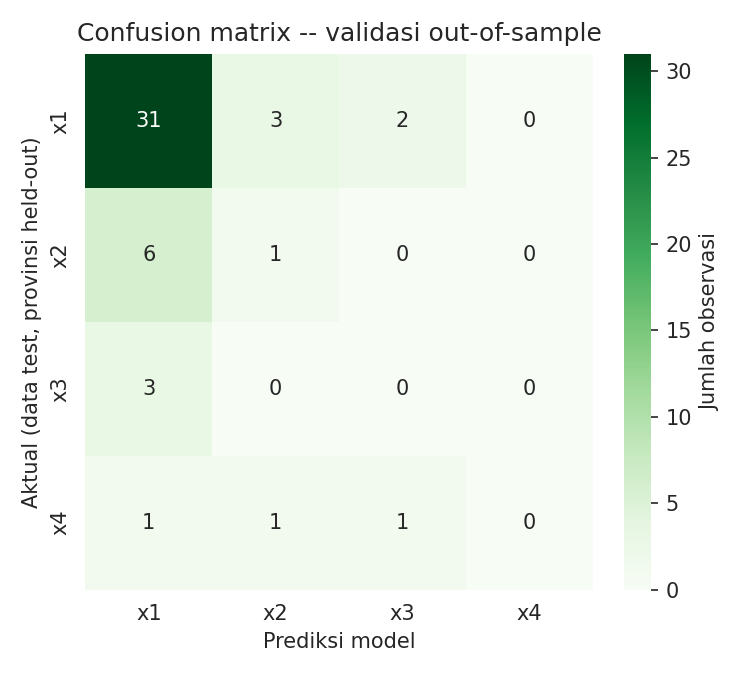

In [ ]:
for img_path in sorted(glob.glob("outputs/transition_model/*.png")):
    display(Image(img_path))


## 7. Fase 8 — Expected Loss & Premium


In [ ]:
!python scripts/10_expected_loss_premium.py --state outputs/state_construction/state_dataset.xlsx --acri outputs/acri/acri_dataset.xlsx


=== Loss Matrix (L_s) ===
       Shortfall_KuHa  Shortfall_Kg_Ha  Loss_Rp_per_Ha  Harga_GKG_dipakai
State                                                                    
x1                0.0             11.0         80327.0             7320.0
x2                2.0            182.0       1334646.0             7320.0
x3                3.0            260.0       1899766.0             7320.0
x4                4.0            431.0       3153380.0             7320.0

=== Premi per provinsi (harga referensi 2025: Rp7,320/kg) ===
                 Provinsi State_awal_r0  Expected_Loss_Rp_per_Ha  Premi_Rp_per_Ha
              Jawa Tengah            x3                   744338          2229944
           Sumatera Barat            x1                   449368          1718394
         Kalimantan Barat            x2                   496447          1678509
           Sulawesi Barat            x1                   437203          1645953
           Sumatera Utara            x1                  

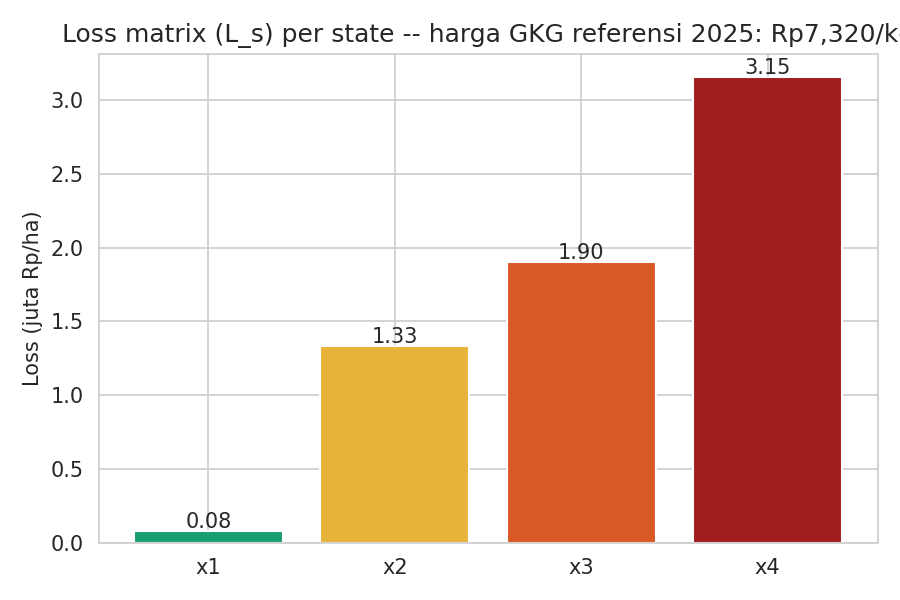

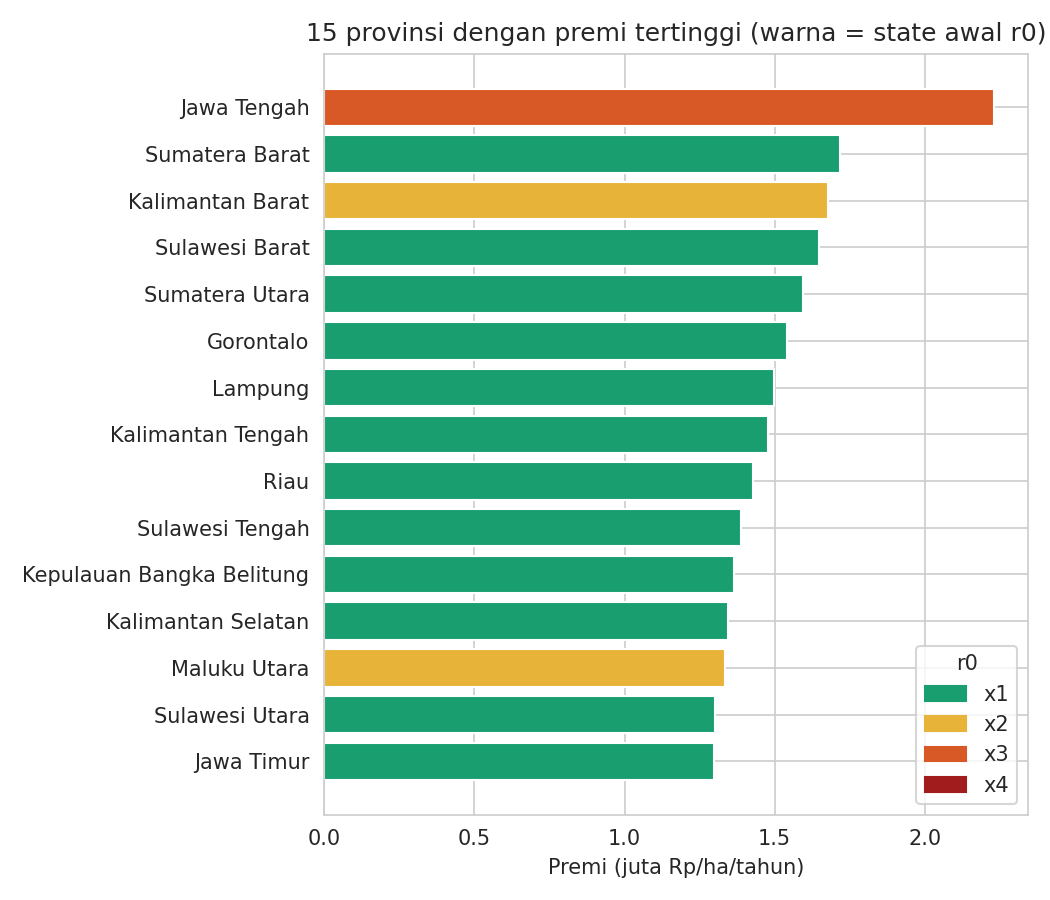

In [ ]:
for img_path in sorted(glob.glob("outputs/premium/*.png")):
    display(Image(img_path))


## 8. Sensitivity Analysis (threshold state)

Menguji seberapa sensitif hasil terhadap pilihan threshold klasifikasi state.


In [ ]:
!python scripts/11_sensitivity_threshold.py --input "{DATA_FILE}" --acri outputs/acri/acri_dataset.xlsx


[McKee_asli_1993 (-1.0/-1.5/-2.0)] x4 cuma 1 observasi (< 5) -- TIDAK LAYAK untuk estimasi model, dilewati dari perbandingan premi.
[Persentil_90_95_99 (-1.28/-1.65/-2.33)] x4 cuma 0 observasi (< 5) -- TIDAK LAYAK untuk estimasi model, dilewati dari perbandingan premi.
[Shift_lebih_ketat (-0.75/-1.25/-1.75)] x4 cuma 2 observasi (< 5) -- TIDAK LAYAK untuk estimasi model, dilewati dari perbandingan premi.
=== Distribusi state per threshold set ===
                          Threshold_set  x1  x2  x3  x4  Total
      Dipakai_pipeline (-0.5/-1.0/-1.5) 180  45  36  11    272
       McKee_asli_1993 (-1.0/-1.5/-2.0) 225  36  10   1    272
 Persentil_90_95_99 (-1.28/-1.65/-2.33) 244  24   4   0    272
Shift_lebih_longgar (-0.25/-0.75/-1.25) 161  42  38  31    272
  Shift_lebih_ketat (-0.75/-1.25/-1.75) 203  38  29   2    272

=== Korelasi ranking premi (Spearman, vs baseline) ===
                          Threshold_set  Spearman_rho_vs_baseline  p_value  n_provinsi
      Dipakai_pipeline (-0.5/

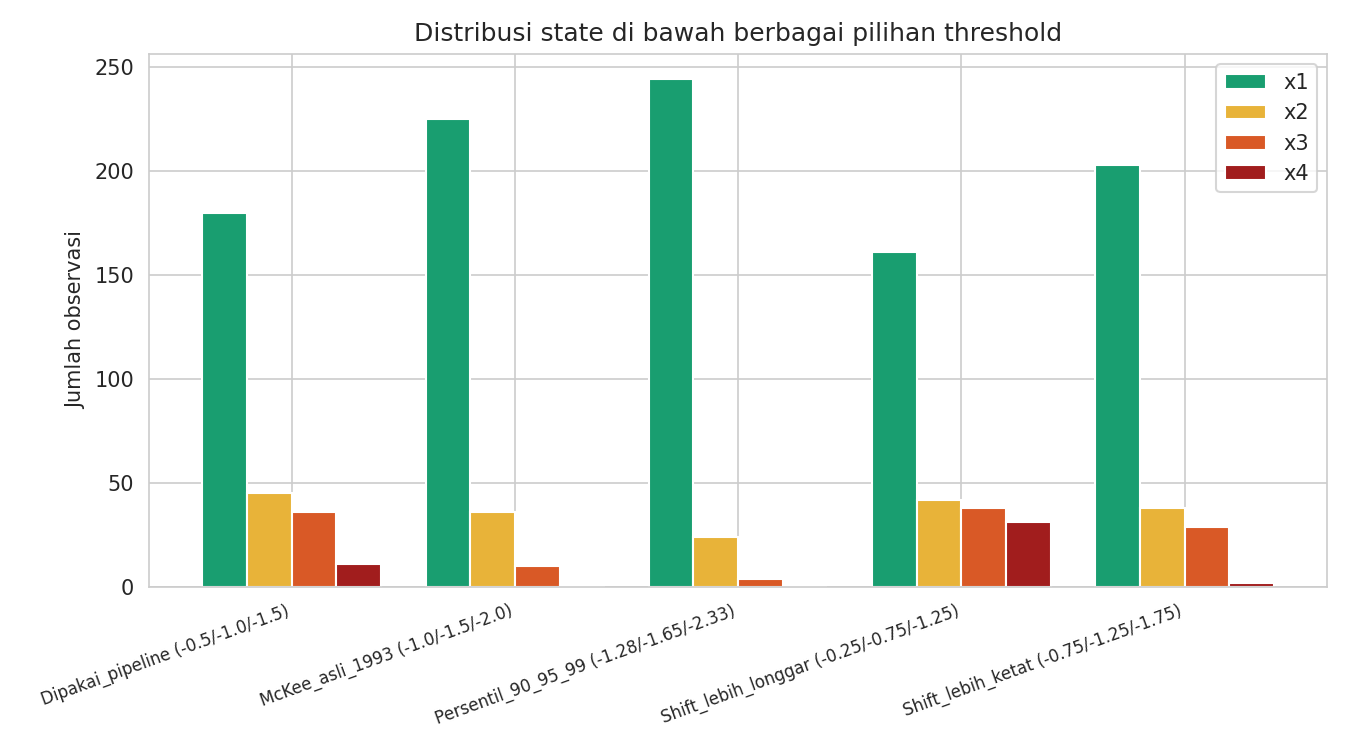

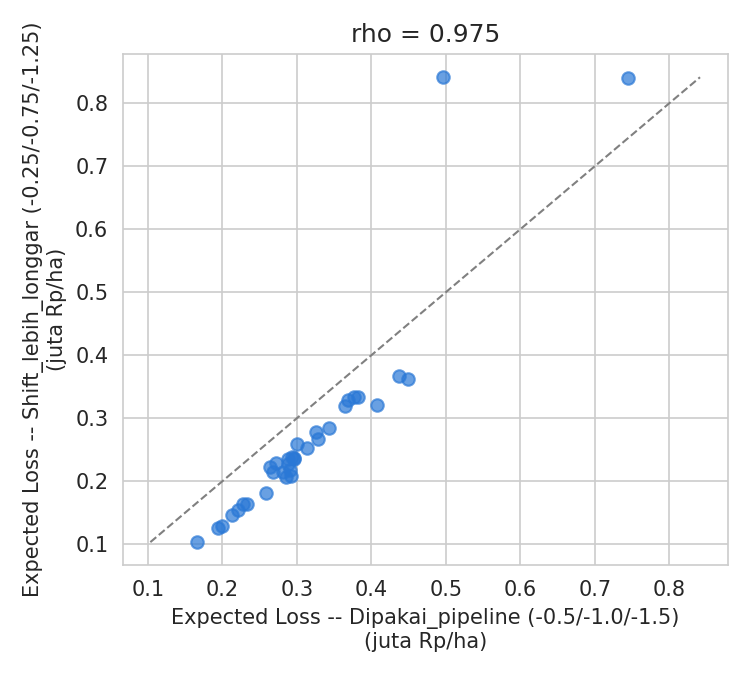

In [ ]:
for img_path in sorted(glob.glob("outputs/sensitivity/*.png")):
    display(Image(img_path))


## 9. Unduh semua hasil

Semua file Excel + grafik dikemas jadi satu zip untuk diunduh.


In [ ]:
!zip -r hasil_fase4_8.zip outputs/
files.download("hasil_fase4_8.zip")


  adding: outputs/ (stored 0%)
  adding: outputs/sensitivity/ (stored 0%)
  adding: outputs/sensitivity/01_distribusi_per_threshold.png (deflated 16%)
  adding: outputs/sensitivity/02_stabilitas_ranking_premi.png (deflated 11%)
  adding: outputs/sensitivity/sensitivity_report.xlsx (deflated 10%)
  adding: outputs/state_construction/ (stored 0%)
  adding: outputs/state_construction/state_dataset.xlsx (deflated 4%)
  adding: outputs/state_construction/01_distribusi_state.png (deflated 13%)
  adding: outputs/state_construction/03_state_over_time.png (deflated 14%)
  adding: outputs/state_construction/02_transisi_heatmap.png (deflated 13%)
  adding: outputs/transition_model/ (stored 0%)
  adding: outputs/transition_model/fitted_models.pkl (deflated 41%)
  adding: outputs/transition_model/02_matriks_P_baseline.png (deflated 10%)
  adding: outputs/transition_model/01_koefisien_gamma.png (deflated 24%)
  adding: outputs/transition_model/03_validasi_confusion.png (deflated 11%)
  adding: outpu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>